In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

In [2]:
vocab_size = 5000              # keep top 5000 frequent words
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [3]:
maxlen = 500                   # maximum tokens per review
x_train = pad_sequences(x_train, maxlen=maxlen)
x_test  = pad_sequences(x_test,  maxlen=maxlen)

In [4]:
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=32, input_length=maxlen),
    LSTM(100),                      # 100 LSTM units
    Dense(1, activation='sigmoid')  # binary output
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [5]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [6]:
history = model.fit(x_train, y_train,
                    epochs=5,
                    batch_size=64,
                    validation_data=(x_test, y_test))

Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 16s 30ms/step - accuracy: 0.6735 - loss: 0.5807 - val_accuracy: 0.8522 - val_loss: 0.3555
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - accuracy: 0.8592 - loss: 0.3405 - val_accuracy: 0.8450 - val_loss: 0.3788
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 12s 31ms/step - accuracy: 0.8877 - loss: 0.2797 - val_accuracy: 0.8676 - val_loss: 0.3229
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 12s 30ms/step - accuracy: 0.9113 - loss: 0.2376 - val_accuracy: 0.8669 - val_loss: 0.3199
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 12s 30ms/step - accuracy: 0.9178 - loss: 0.2108 - val_accuracy: 0.8607 - val_loss: 0.3344


In [7]:
loss, acc = model.evaluate(x_test, y_test, verbose=1)
print(f"Test Accuracy: {acc:.4f}")

782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8580 - loss: 0.3435
Test Accuracy: 0.8607


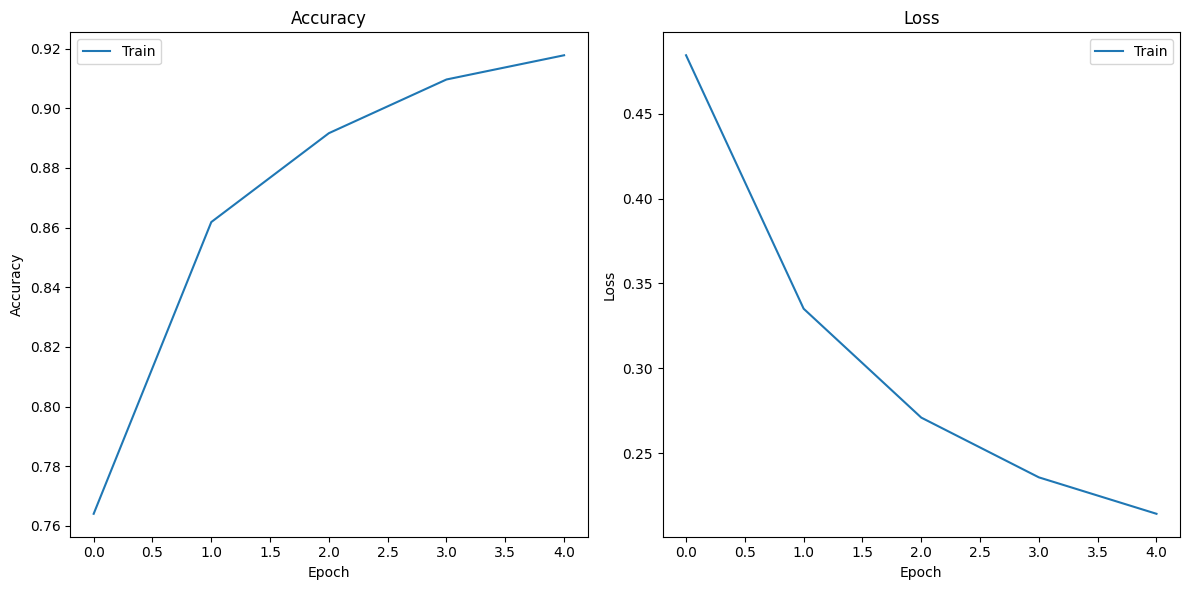

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()